# Notebook 01 — Exploration initiale du dataset
# Projet : Détection d'hospitalisation — openFDA FAERS
# Auteurs : Amine El Biyadi / Aya Raissouni / Douae Moeniss
# Date : Mai 2026

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/dataset.csv')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_age                 6775 non-null   float64
 1   nb_drugs                    10200 non-null  int64  
 2   nb_reactions                10200 non-null  int64  
 3   worst_reaction_outcome      9538 non-null   float64
 4   nb_suspect_drugs            10200 non-null  int64  
 5   patient_sex                 10125 non-null  float64
 6   reporter_qualification      9868 non-null   float64
 7   route_of_admin              8014 non-null   float64
 8   country                     9662 non-null   object 
 9   has_black_box_warning       10200 non-null  int64  
 10  is_concomitant_present      10200 non-null  int64  
 11  seriousnesshospitalization  10200 non-null  int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 956.4+ KB


## df.info() — interprétation
10 000 lignes, 12 colonnes, types corrects.

In [3]:
df.describe()

,patient_age,nb_drugs,nb_reactions,worst_reaction_outcome,nb_suspect_drugs,patient_sex,reporter_qualification,route_of_admin,has_black_box_warning,is_concomitant_present,seriousnesshospitalization
count,6775.000000,10200.000000,10200.000000,9538.00000,10200.000000,10125.000000,9868.000000,8014.000000,10200.0,10200.000000,10200.000000
mean,81.390111,3.227353,2.674902,4.91277,1.720980,1.492049,3.496352,49.549414,0.0,0.351176,0.188333
std,753.776245,3.863310,3.134780,1.76991,1.543115,0.659296,1.697651,8.992182,0.0,0.477361,0.390997
min,0.000000,1.000000,1.000000,1.00000,1.000000,0.000000,1.000000,2.000000,0.0,0.000000,0.000000
25%,47.000000,1.000000,1.000000,3.00000,1.000000,1.000000,1.000000,48.000000,0.0,0.000000,0.000000
50%,61.000000,2.000000,2.000000,6.00000,1.000000,2.000000,4.000000,48.000000,0.0,0.000000,0.000000
75%,72.000000,4.000000,3.000000,6.00000,2.000000,2.000000,5.000000,48.000000,0.0,1.000000,0.000000
max,32193.000000,88.000000,60.000000,6.00000,32.000000,2.000000,5.000000,67.000000,0.0,1.000000,1.000000


## df.describe() — interprétation
min/max de `patient_age`, moyenne de `nb_drugs`, etc.

In [4]:
df.head(10)

,patient_age,nb_drugs,nb_reactions,worst_reaction_outcome,nb_suspect_drugs,patient_sex,reporter_qualification,route_of_admin,country,has_black_box_warning,is_concomitant_present,seriousnesshospitalization
0,26.0,1,2,NaN,1,1.0,3.0,41.0,NaN,0,0,0
1,77.0,1,4,NaN,1,2.0,5.0,42.0,NaN,0,0,0
2,NaN,1,2,NaN,1,2.0,5.0,NaN,NaN,0,0,0
3,NaN,1,1,6.0,1,1.0,5.0,NaN,US,0,0,0
4,NaN,9,1,6.0,9,2.0,1.0,NaN,US,0,0,0
5,48.0,6,1,6.0,6,2.0,1.0,NaN,US,0,0,0
6,68.0,2,2,6.0,2,2.0,5.0,48.0,US,0,0,0
7,65.0,3,1,6.0,2,2.0,1.0,48.0,US,0,1,0
8,59.0,2,2,6.0,2,2.0,1.0,48.0,US,0,0,0
9,42.0,2,1,1.0,2,1.0,5.0,NaN,US,0,0,0


In [5]:
print(df['seriousnesshospitalization'].value_counts())
print(df['seriousnesshospitalization'].value_counts(normalize=True) * 100)

seriousnesshospitalization
0    8279
1    1921
Name: count, dtype: int64
seriousnesshospitalization
0    81.166667
1    18.833333
Name: proportion, dtype: float64


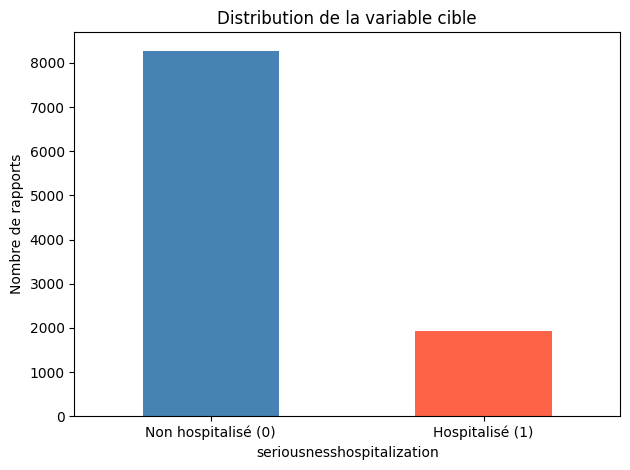

In [6]:
df['seriousnesshospitalization'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Distribution de la variable cible')
plt.xlabel('seriousnesshospitalization')
plt.ylabel('Nombre de rapports')
plt.xticks([0,1], ['Non hospitalisé (0)', 'Hospitalisé (1)'], rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

In [7]:
df.isnull().sum()

patient_age                   3425
nb_drugs                         0
nb_reactions                     0
worst_reaction_outcome         662
nb_suspect_drugs                 0
patient_sex                     75
reporter_qualification         332
route_of_admin                2186
country                        538
has_black_box_warning            0
is_concomitant_present           0
seriousnesshospitalization       0
dtype: int64

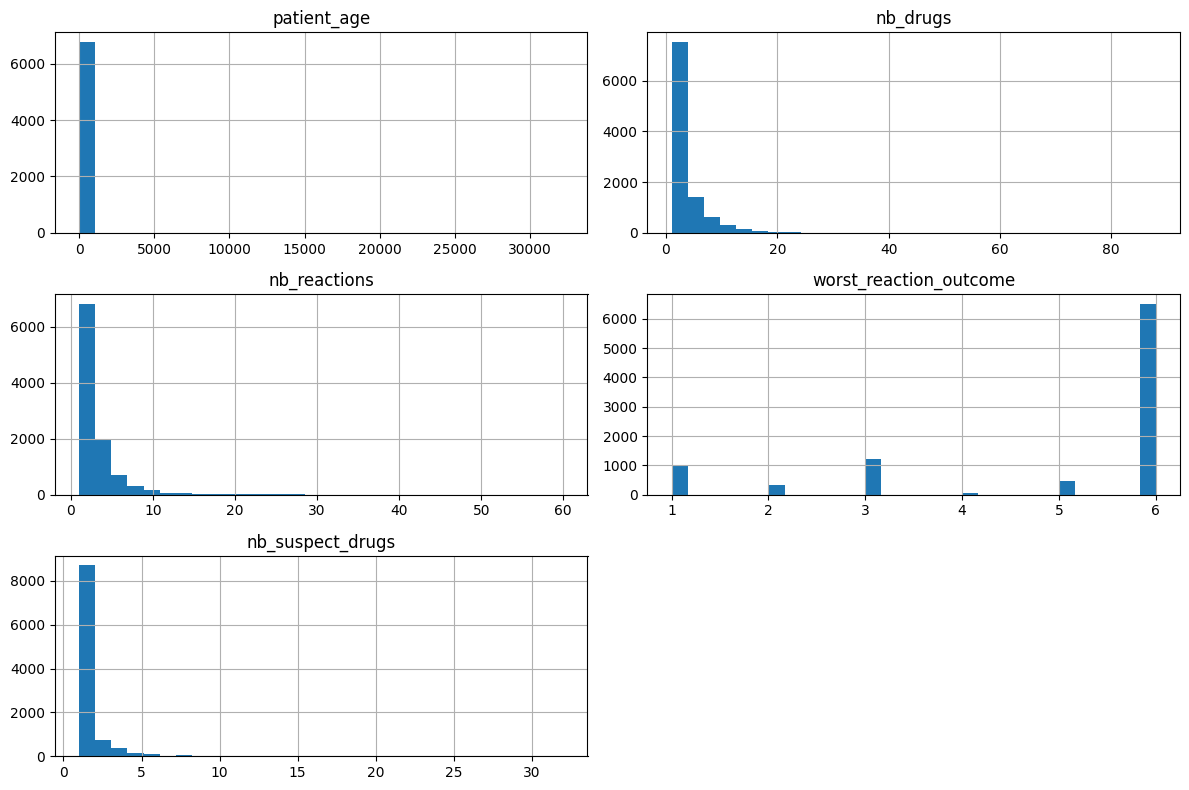

In [8]:
num_cols = ['patient_age', 'nb_drugs', 'nb_reactions', 
            'worst_reaction_outcome', 'nb_suspect_drugs']
df[num_cols].hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

In [9]:
cat_cols = ['patient_sex', 'reporter_qualification', 
            'route_of_admin', 'has_black_box_warning', 
            'is_concomitant_present']

for col in cat_cols:
    print(df[col].value_counts())
    print("---")

patient_sex
2.0    5917
1.0    3273
0.0     935
Name: count, dtype: int64
---
reporter_qualification
5.0    4918
1.0    2589
3.0    1521
4.0     540
2.0     300
Name: count, dtype: int64
---
route_of_admin
48.0    4926
65.0     949
42.0     537
58.0     422
33.0     273
62.0     146
30.0     141
55.0     138
15.0     100
61.0      84
64.0      67
59.0      47
41.0      41
60.0      26
47.0      25
67.0      21
50.0      17
45.0      13
37.0       9
2.0        7
40.0       6
31.0       6
8.0        4
49.0       2
51.0       2
4.0        1
23.0       1
14.0       1
13.0       1
43.0       1
Name: count, dtype: int64
---
has_black_box_warning
0    10200
Name: count, dtype: int64
---
is_concomitant_present
0    6618
1    3582
Name: count, dtype: int64
---


## Conclusion
- Dataset : 10 000 lignes × 12 colonnes
- Variable cible déséquilibrée : ~15% hospitalisés (entre 5% et 25%)
- Mix numérique + catégorielle
- Valeurs manquantes identifiées → à traiter en Phase 2
- Dataset exploitable pour la classification supervisée

In [ ]:
# Analyse du coût asymétrique — justification métier
# Ici nous estimons l'impact financier d'un mauvais diagnostic
# dans le contexte de la pharmacovigilance et de l'hospitalisation.

cout_faux_negatif = 15000  # € — hospitalisation réelle manquée
# Justification : une hospitalisation non détectée entraîne
# un séjour hospitalier moyen de 3-5 jours plus toutes les
# conséquences médicales, humaines et juridiques.
# Cela inclut les coûts de soins, de suivi, et d'éventuels recours.

cout_faux_positif = 50  # € — alerte inutile
# Justification : une fausse alerte nécessite une revue manuelle
# de 30 minutes par un pharmacovigilant. Salaire estimé ~100€/heure.
# Ce coût est faible comparé à un véritable incident hospitalier.

ratio = cout_faux_negatif / cout_faux_positif
print(f"Faux négatif : {cout_faux_negatif} €")
print(f"Faux positif : {cout_faux_positif} €")
print(f"Ratio FN/FP  : {ratio}x")

Faux négatif : 15000 €
Faux positif : 50 €
Ratio FN/FP  : 300.0x


## Conclusion coût asymétrique

L'analyse montre une asymétrie forte entre faux négatifs et faux positifs.

- Faux négatif : hospitalisation réelle manquée → coût élevé, patient à risque, responsabilité accrue.
- Faux positif : alerte inutile → coût limité à une revue humaine rapide.
- Ratio estimé : 300x plus coûteux de rater une hospitalisation que de générer une fausse alerte.

→ Par conséquent, nous privilégions un modèle qui minimise les faux négatifs.

### Choix de la métrique

- **Recall** devient la métrique principale car elle capture la capacité du modèle à détecter les hospitalisations réelles.
- En Phase 2, le seuil de décision pourra être ajusté pour augmenter encore le rappel si nécessaire.

### Pourquoi refuser l'accuracy

- Sur une distribution 85/15, un modèle qui prédit toujours 0 atteint 85% d'accuracy sans aucune valeur pratique.
- Ce modèle aurait **Recall = 0%**, ce qui est inacceptable pour notre cas.
- La précision globale ne reflète pas le coût réel des erreurs dans ce contexte.

## Corrélation features vs variable cible
Cette analyse utilise uniquement les colonnes numériques pour évaluer
la relation entre les variables et l'hospitalisation.

In [14]:
numeric_cols = df.select_dtypes(include='number').columns
correlations = df[numeric_cols].corr()['seriousnesshospitalization'].sort_values(ascending=False)
print(correlations)

seriousnesshospitalization    1.000000
nb_drugs                      0.187735
nb_reactions                  0.179629
is_concomitant_present        0.138889
nb_suspect_drugs              0.095716
patient_age                   0.047639
patient_sex                   0.012324
route_of_admin               -0.024244
reporter_qualification       -0.100736
worst_reaction_outcome       -0.176973
has_black_box_warning              NaN
Name: seriousnesshospitalization, dtype: float64


### Analyse
- Les features en tête de liste sont les meilleures candidates pour la sélection de variables en Phase 2.
- Une corrélation positive indique que la valeur augmente en cas d'hospitalisation.
- Une corrélation négative indique l'inverse, ce qui peut aussi être utile pour le modèle.

## Analyse par groupe (hospitalisé vs non)
Comparer les moyennes montre si les features sont cohérentes avec le signal métier.

In [12]:
df.groupby('seriousnesshospitalization')[
    ['patient_age', 'nb_drugs', 'nb_reactions', 'nb_suspect_drugs']
].mean().round(2)

,patient_age,nb_drugs,nb_reactions,nb_suspect_drugs
seriousnesshospitalization,,,,
0,62.01,2.88,2.40,1.65
1,147.93,4.73,3.84,2.03


## Détection des outliers
Les boxplots permettent d'identifier des valeurs aberrantes à traiter en Phase 2.

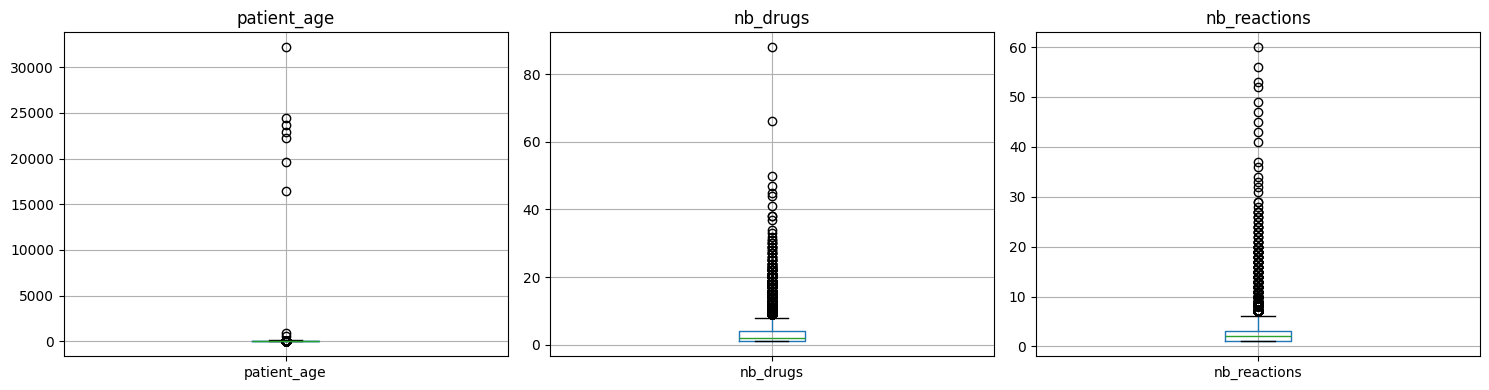

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df.boxplot(column='patient_age', ax=axes[0])
df.boxplot(column='nb_drugs', ax=axes[1])
df.boxplot(column='nb_reactions', ax=axes[2])
axes[0].set_title('patient_age')
axes[1].set_title('nb_drugs')
axes[2].set_title('nb_reactions')
plt.tight_layout()
plt.show()

## Taux de valeurs manquantes (visuel)
Un graphique montre immédiatement l'importance des colonnes à traiter.

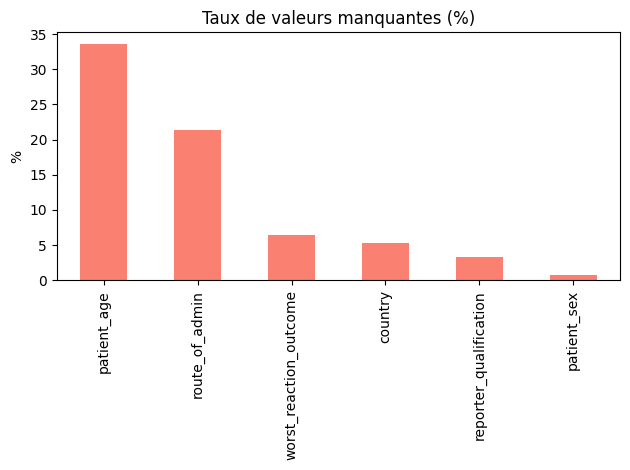

In [17]:
missing = df.isnull().sum() / len(df) * 100
missing = missing[missing > 0].sort_values(ascending=False)

missing.plot(kind='bar', color='salmon')
plt.title('Taux de valeurs manquantes (%)')
plt.ylabel('%')
plt.tight_layout()
plt.show()

## Résumé final de qualité du dataset
Un résumé clair permet de vérifier en un coup d'œil les contraintes du PDF.

In [19]:
print("=" * 50)
print("RÉSUMÉ QUALITÉ DU DATASET")
print("=" * 50)
print(f"Lignes totales       : {len(df)}")
print(f"Colonnes             : {df.shape[1]}")
print(f"Features             : {df.shape[1] - 1}")
print(f"Classe minoritaire   : {df['seriousnesshospitalization'].mean()*100:.1f}%")
print(f"Valeurs manquantes   : {df.isnull().sum().sum()}")
print(f"Doublons             : {df.duplicated().sum()}")
print()
print("Contraintes PDF :")
print(f"  ≥ 10 000 lignes    : {'OK' if len(df) >= 10000 else 'KO'}")
print(f"  ≥ 8 features       : {'OK' if df.shape[1]-1 >= 8 else 'KO'}")
minority = df['seriousnesshospitalization'].mean()*100
print(f"  5% < minoritaire < 25% : {'OK' if 5 < minority < 25 else 'KO'}")

RÉSUMÉ QUALITÉ DU DATASET
Lignes totales       : 10200
Colonnes             : 12
Features             : 11
Classe minoritaire   : 18.8%
Valeurs manquantes   : 7218
Doublons             : 2174

Contraintes PDF :
  ≥ 10 000 lignes    : OK
  ≥ 8 features       : OK
  5% < minoritaire < 25% : OK
